# 0. Instalar pacotes e importar bibliotecas

In [1]:
!pip install optuna # Tunar hiperparâmetro
!pip install category_encoders
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable


ERROR: Invalid requirement: '#'


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Dependências
import sys
#!{sys.executable} -m pip install --disable-pip-version-check -r ../requirements.txt -q
print('Bibliotecas instaladas')

Bibliotecas instaladas


In [3]:
# Dependências
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Diretórios
from configs.paths import *
from configs.function_basic import *
from configs.function_others import *

import numpy             as np
import matplotlib.pyplot as plt
import matplotlib        as mpl
import pandas            as pd
import seaborn           as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, ShuffleSplit
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, \
HistGradientBoostingClassifier,StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, f1_score, make_scorer, accuracy_score, precision_score, recall_score, auc, precision_recall_curve, average_precision_score
import optuna
import pickle
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB

Diretórios carregados com sucesso
Funções básicas carregadas com sucesso
Funções auxiliares carregadas com sucesso


# 1. Funções auxiliares

In [4]:
# Métricas do modelo

def calculate_metrics(nm_modelo, model, X_train, y_train, X_test, y_test):
    # Fazendo predições
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculando as métricas para o conjunto de treino
    accuracy_train = accuracy_score(y_train, y_train_pred)
    precision_train = precision_score(y_train, y_train_pred)
    recall_train = recall_score(y_train, y_train_pred)
    auc_roc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])

    # Calculando o Índice Gini e Estatística KS para o conjunto de treino
    probabilities_train = model.predict_proba(X_train)[:, 1]
    df_train = pd.DataFrame({'true_labels': y_train, 'predicted_probs': probabilities_train})
    df_train = df_train.sort_values(by='predicted_probs', ascending=False)
    df_train['cumulative_true'] = df_train['true_labels'].cumsum() / df_train['true_labels'].sum()
    df_train['cumulative_false'] = (1 - df_train['true_labels']).cumsum() / (1 - df_train['true_labels']).sum()
    ks_statistic_train = max(abs(df_train['cumulative_true'] - df_train['cumulative_false']))
    gini_index_train = 2 * auc_roc_train - 1

    # Calculando as métricas para o conjunto de teste
    accuracy_test = accuracy_score(y_test, y_test_pred)
    precision_test = precision_score(y_test, y_test_pred)
    recall_test = recall_score(y_test, y_test_pred)
    auc_roc_test = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    # Calculando o Índice Gini e Estatística KS para o conjunto de teste
    probabilities_test = model.predict_proba(X_test)[:, 1]
    df_test = pd.DataFrame({'true_labels': y_test, 'predicted_probs': probabilities_test})
    df_test = df_test.sort_values(by='predicted_probs', ascending=False)
    df_test['cumulative_true'] = df_test['true_labels'].cumsum() / df_test['true_labels'].sum()
    df_test['cumulative_false'] = (1 - df_test['true_labels']).cumsum() / (1 - df_test['true_labels']).sum()
    ks_statistic_test = max(abs(df_test['cumulative_true'] - df_test['cumulative_false']))
    gini_index_test = 2 * auc_roc_test - 1

    # Criando o DataFrame com as métricas calculadas
    metrics_df = pd.DataFrame({
        'Algoritmo': [nm_modelo, nm_modelo],
        'Conjunto': ['Treino', 'Teste'],
        'Acuracia': [accuracy_train, accuracy_test],
        'Precisao': [precision_train, precision_test],
        'Recall': [recall_train, recall_test],
        'AUC_ROC': [auc_roc_train, auc_roc_test],
        'GINI': [gini_index_train, gini_index_test],
        'KS': [ks_statistic_train, ks_statistic_test]
    })
    return metrics_df

def calculate_metrics_train(nm_modelo, X_train, y_train):
    # Fazendo predições
    y_train_prob = X_train.SCORE_FRAUDE
    y_train_pred = (y_train_prob > 0.5).astype(int)

    # Calculando as métricas para o conjunto de treino
    accuracy_train = accuracy_score(y_train, y_train_pred)
    precision_train = precision_score(y_train, y_train_pred)
    recall_train = recall_score(y_train, y_train_pred)
    auc_roc_train = roc_auc_score(y_train, y_train_prob)

    # Calculando o Índice Gini e Estatística KS para o conjunto de treino
    probabilities_train = y_train_prob
    df_train = pd.DataFrame({'true_labels': y_train, 'predicted_probs': probabilities_train})
    df_train = df_train.sort_values(by='predicted_probs', ascending=False)
    df_train['cumulative_true'] = df_train['true_labels'].cumsum() / df_train['true_labels'].sum()
    df_train['cumulative_false'] = (1 - df_train['true_labels']).cumsum() / (1 - df_train['true_labels']).sum()
    ks_statistic_train = max(abs(df_train['cumulative_true'] - df_train['cumulative_false']))
    gini_index_train = 2 * auc_roc_train - 1

    # Criando o DataFrame com as métricas calculadas
    metrics_df = pd.DataFrame({
        'Algoritmo': [nm_modelo],
        'Conjunto': ['Treino'],
        'Acuracia': [accuracy_train],
        'Precisao': [precision_train],
        'Recall': [recall_train],
        'AUC_ROC': [auc_roc_train],
        'GINI': [gini_index_train],
        'KS': [ks_statistic_train]
    })
    return metrics_df

def plot_metrics(model, X_train, y_train, X_test, y_test, features):
    plt.figure(figsize=(15, 18))

    # Gráfico de Barras para Taxa do Evento e Importância das Variáveis
    plt.subplot(4, 2, 1)
    event_rate = y_train.mean()
    non_event_rate = 1 - event_rate
    plt.barh(['Não Evento', 'Evento'], [non_event_rate, event_rate], color=['lightsteelblue', 'skyblue'])
    plt.xlabel('Taxa')
    plt.title('Taxa do Evento')

    plt.subplot(4, 2, 2)
    importances = model.feature_importances_
    indices = np.argsort(importances)  # Ordem ascendente
    indices = indices[-10:]  # Considerando apenas as 10 mais importantes
    plt.barh(features[indices], importances[indices], color='skyblue')
    plt.xlabel('Importância')
    plt.title('Importância das Variáveis')

    # Curva ROC para Treino e Teste
    plt.subplot(4, 2, 3)
    for X, y, label in [(X_train, y_train, 'Treino'), (X_test, y_test, 'Teste')]:
        fpr, tpr, _ = roc_curve(y, model.predict_proba(X)[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')

    # Gráfico de Barras para Gini e KS
    plt.subplot(4, 2, 4)
    metrics = ['Índice Gini', 'Estatística KS']
    for X, y, label in [(X_train, y_train, 'Treino'), (X_test, y_test, 'Teste')]:
        probs = model.predict_proba(X)[:, 1]
        df = pd.DataFrame({'true_labels': y, 'predicted_probs': probs})
        df = df.sort_values(by='predicted_probs', ascending=False)
        df['cumulative_true'] = df['true_labels'].cumsum() / df['true_labels'].sum()
        df['cumulative_false'] = (1 - df['true_labels']).cumsum() / (1 - df['true_labels']).sum()
        ks = max(abs(df['cumulative_true'] - df['cumulative_false']))
        gini = 2 * auc(*roc_curve(y, probs)[:2]) - 1
        plt.bar([f'{label}\n{metric}' for metric in metrics], [gini, ks], color='skyblue')
    plt.title('Índice Gini e Estatística KS')

    # Matrizes de Confusão para Treino e Teste
    for i, (X, y, label) in enumerate([(X_train, y_train, 'Treino'), (X_test, y_test, 'Teste')], 5):
        plt.subplot(4, 2, i)
        conf_matrix = confusion_matrix(y, model.predict(X))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Matriz de Confusão - {label}')

    # Histograma do Score para Treino e Teste
    plt.subplot(4, 2, 7)
    plt.hist(model.predict_proba(X_train)[:, 1], bins=30, color='skyblue', edgecolor='black', alpha=0.7, label='Treino')
    plt.xlabel('Score')
    plt.ylabel('Frequência')
    plt.title('Histograma do Score - Treino')
    plt.legend(loc='upper right')

    plt.subplot(4, 2, 8)
    plt.hist(model.predict_proba(X_test)[:, 1], bins=30, color='lightsteelblue', edgecolor='black', alpha=0.7, label='Teste')
    plt.xlabel('Score')
    plt.ylabel('Frequência')
    plt.title('Histograma do Score - Teste')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# 2. Leitura dos datasets

In [5]:
# Carregar dados CORRIGIDOS conforme solicitado
df_train = pd.read_csv(PROCESSED_DIR / 'abt01_train.csv')
df_test = pd.read_csv(PROCESSED_DIR / 'abt01_test.csv')

print(f'📊 Treino: {df_train.shape}')
print(f'📊 Teste: {df_test.shape}')
print(f'\n🎯 Distribuição do Target (Treino):')
print(f"  Treino: {(df_train['FPD'].value_counts(normalize=True) * 100).round(2)}")

📊 Treino: (831081, 67)
📊 Teste: (389550, 67)

🎯 Distribuição do Target (Treino):
  Treino: 0    76.82
1    23.18
Name: FPD, dtype: float64


In [6]:
#df_train = pd.read_csv('/content/drive/MyDrive/Prevencao_fraude/df_train_full.csv')
#df_test = pd.read_csv('/content/drive/MyDrive/Prevencao_fraude/df_test_full.csv')

#abt_vigente = pd.read_csv('/content/drive/MyDrive/Prevencao_fraude/abt_vigente_score.csv')

# Colocando nomes das colunas em maiúsculo
df_train.columns = df_train.columns.str.upper()
df_test.columns = df_test.columns.str.upper()
#abt_vigente.columns = abt_vigente.columns.str.upper()

In [7]:
df_train.head()

,SCORE_01,SCORE_02,SCORE_MIN,VAR_03,VAR_04,VAR_05,CEP_3_DIGITOS,IDADE,APOSENTADO,AUX_EMRG,...,VAR_86,VAR_87,VAR_88,VAR_89,VAR_91,VAR_92,VAR_93,REGIAO_POSTAL_TXT_ENC,SAFRA,FPD
0,562.0,636.0,562.0,33.0,0.0,2.0,479.0,40.0,0.0,0.0,...,2.0,3.0,1.0,50.0,2.0,1.0,1.0,3.0,202410,0
1,546.0,518.0,518.0,14.0,0.0,2.0,690.0,43.0,0.0,0.0,...,304.0,304.0,304.0,304.0,304.0,304.0,304.0,5.0,202410,1
2,621.0,750.0,621.0,33.0,0.0,4.0,790.0,42.0,0.0,0.0,...,0.0,1.0,1.0,100.0,1.0,1.0,2.0,0.0,202410,0
3,609.0,679.0,609.0,50.0,0.0,1.0,691.0,36.0,0.0,1.0,...,304.0,304.0,304.0,304.0,304.0,304.0,304.0,5.0,202410,1
4,621.0,722.0,621.0,33.0,0.0,2.0,758.0,40.0,0.0,0.0,...,304.0,304.0,304.0,304.0,304.0,304.0,304.0,0.0,202410,0


# 3. Preparação dos Dados

In [8]:
# Separar features e target
X = df_train.drop(columns=['FPD'])
y = df_train['FPD']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=0,
    stratify=y  # importante para fraude
)

# Como já está pré-processado:
X_train_processed = X_train
X_test_processed  = X_test


In [9]:
X_train_processed.head()

,SCORE_01,SCORE_02,SCORE_MIN,VAR_03,VAR_04,VAR_05,CEP_3_DIGITOS,IDADE,APOSENTADO,AUX_EMRG,...,VAR_85,VAR_86,VAR_87,VAR_88,VAR_89,VAR_91,VAR_92,VAR_93,REGIAO_POSTAL_TXT_ENC,SAFRA
605928,540.0,541.0,540.0,3.0,0.0,1.0,980.0,34.0,0.0,0.0,...,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,10.0,202412
794094,562.0,606.0,562.0,1.0,0.0,1.0,357.0,57.0,0.0,1.0,...,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,2.0,202501
130119,549.0,577.0,549.0,33.0,0.0,2.0,99.0,47.0,0.0,0.0,...,304.0,304.0,304.0,6.0,304.0,304.0,2.0,304.0,7.0,202410
659945,543.0,505.0,505.0,33.0,0.0,1.0,684.0,29.0,0.0,0.0,...,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,5.0,202501
159908,623.0,636.0,623.0,98.0,0.0,2.0,266.0,65.0,1.0,1.0,...,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,6.0,202410


# 4. Modelagem

In [10]:
# Testar outros modelos

algoritmos = [DecisionTreeClassifier(criterion='gini',random_state=0),
            LogisticRegression(solver='liblinear',random_state=0),
            RandomForestClassifier(random_state=0),
            GradientBoostingClassifier(random_state=0),
            XGBClassifier(random_state=0),
            lgb.LGBMClassifier(random_state=0)]

for algoritmo in algoritmos:

    nome_algoritmo = str(algoritmo)[:str(algoritmo).find("(")]
    # Treino do modelo
    algoritmo.fit(X_train_processed,y_train)

    # Avaliar modelo
    metricas = calculate_metrics(nome_algoritmo,algoritmo, X_train_processed, y_train, X_test_processed, y_test)
    display(metricas)

,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,DecisionTreeClassifier,Treino,0.999905,0.999929,0.999663,1.000000,1.000000,0.999872
1,DecisionTreeClassifier,Teste,0.666460,0.298522,0.325080,0.547317,0.094634,0.094841


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,LogisticRegression,Treino,0.770917,0.541182,0.077546,0.703060,0.406121,0.296589
1,LogisticRegression,Teste,0.771383,0.548032,0.078766,0.701226,0.402451,0.291764


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,RandomForestClassifier,Treino,0.999896,0.999844,0.999708,0.999997,0.999995,0.999838
1,RandomForestClassifier,Teste,0.770986,0.528865,0.110791,0.692311,0.384622,0.279509


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,GradientBoostingClassifier,Treino,0.773290,0.573941,0.085539,0.710668,0.421336,0.305860
1,GradientBoostingClassifier,Teste,0.772677,0.565240,0.083982,0.708061,0.416121,0.301998


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,XGBClassifier,Treino,0.779192,0.622815,0.120439,0.736253,0.472505,0.342167
1,XGBClassifier,Teste,0.772965,0.553723,0.106327,0.708515,0.417030,0.302614


[LightGBM] [Info] Number of positive: 154128, number of negative: 510736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3859
[LightGBM] [Info] Number of data points in the train set: 664864, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.231819 -> initscore=-1.198069
[LightGBM] [Info] Start training from score -1.198069


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,LGBMClassifier,Treino,0.774980,0.585977,0.099936,0.718371,0.436742,0.316997
1,LGBMClassifier,Teste,0.773627,0.568654,0.097270,0.710359,0.420718,0.304874


# 5. Avaliação da Performance do Modelo Vigente

## 6. Visualização de algumas métricas para o algoritmo que teve melhor desempenho

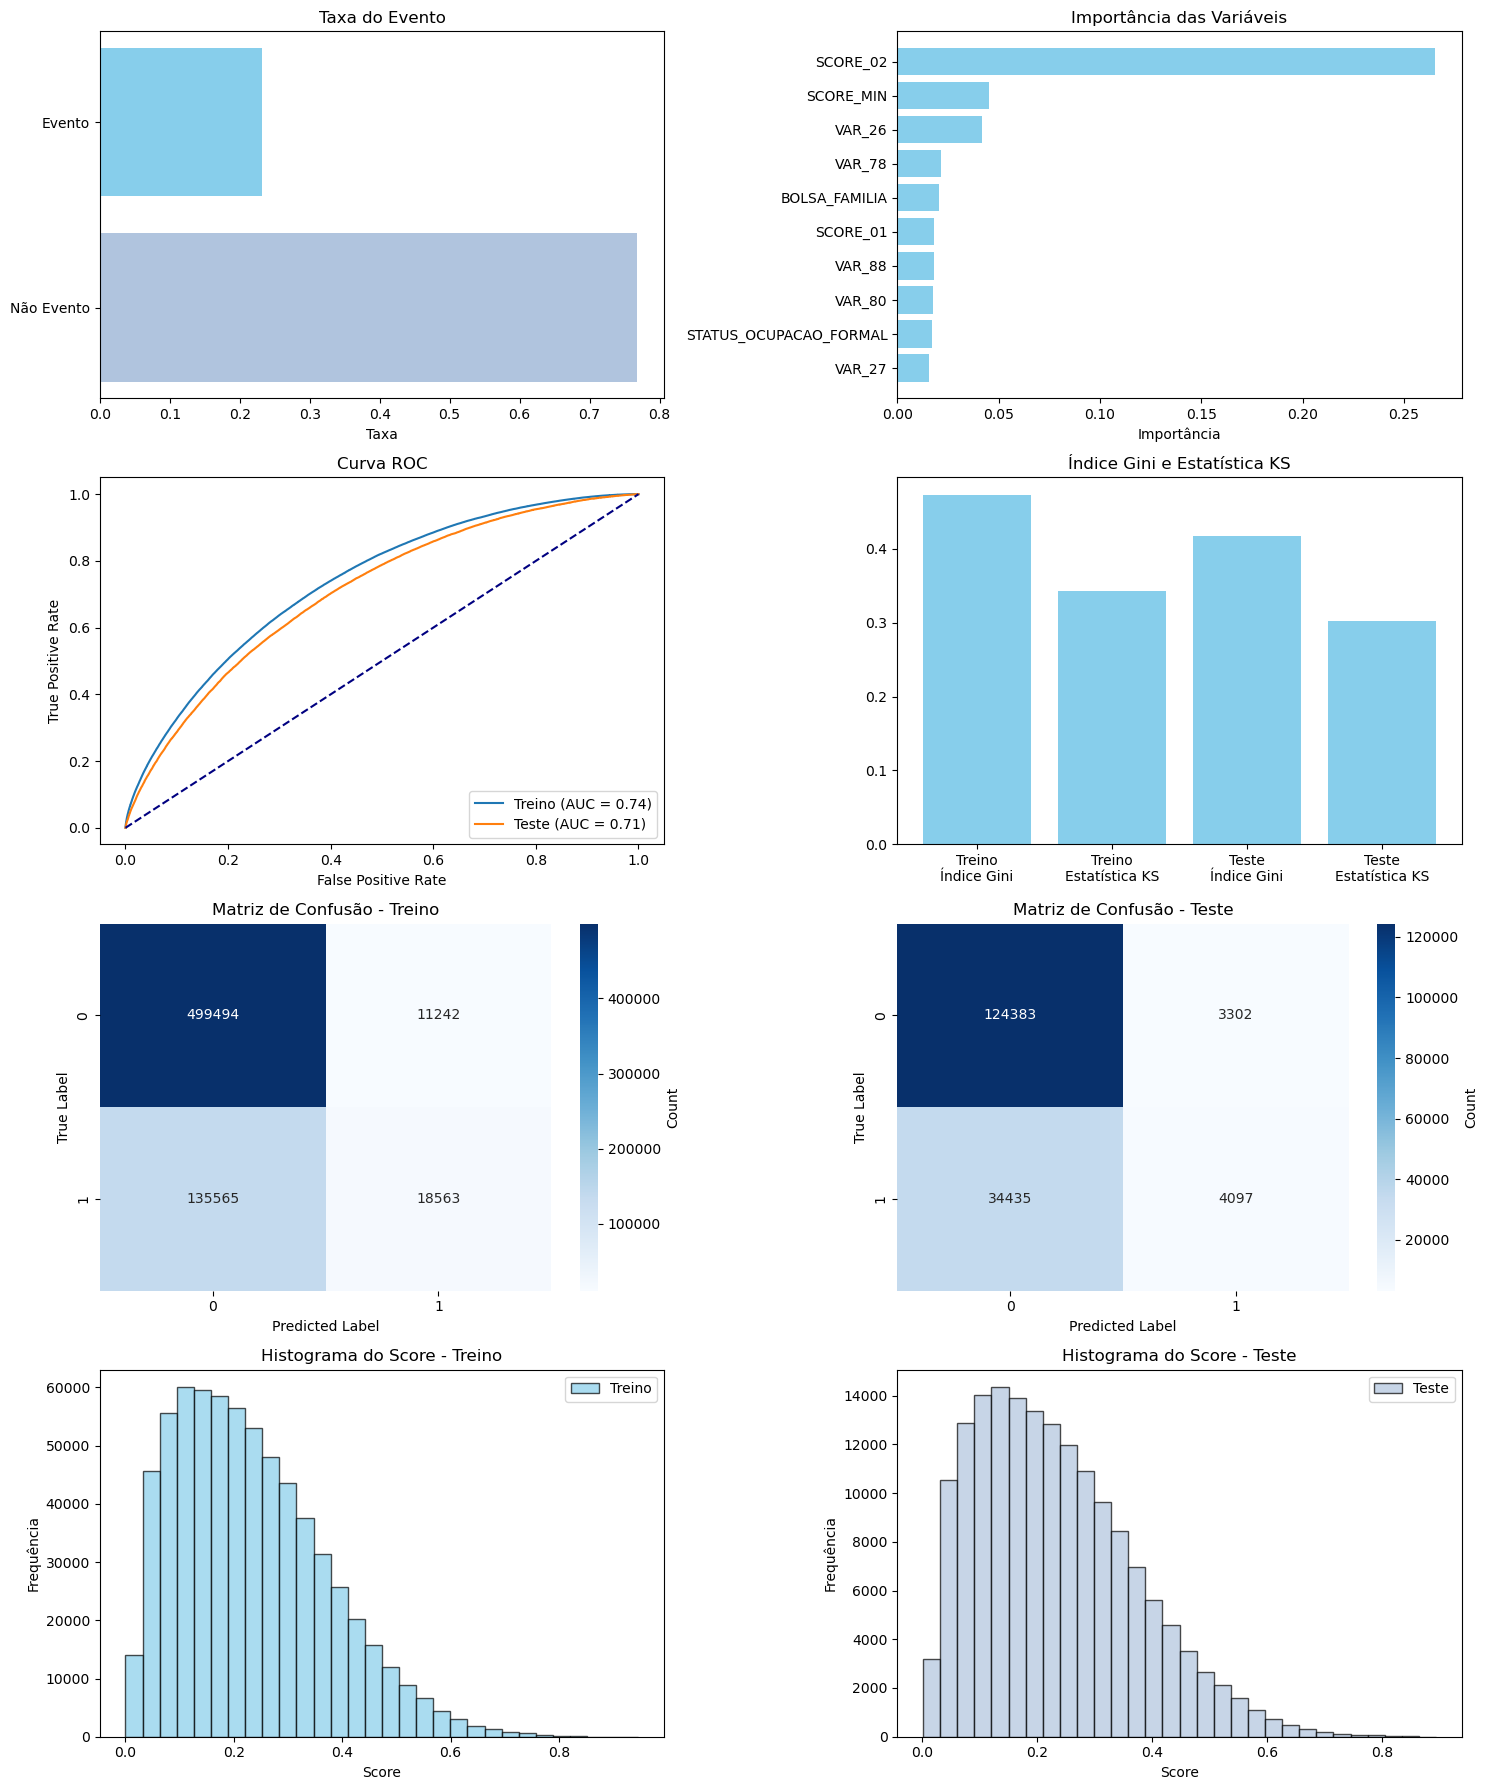

In [11]:
features = X_train_processed.columns
best_algorithm = XGBClassifier(random_state=0)
best_algorithm.fit(X_train_processed,y_train)
plot_metrics(best_algorithm, X_train_processed, y_train, X_test_processed, y_test, features)

## 7. Curva Precision Recall

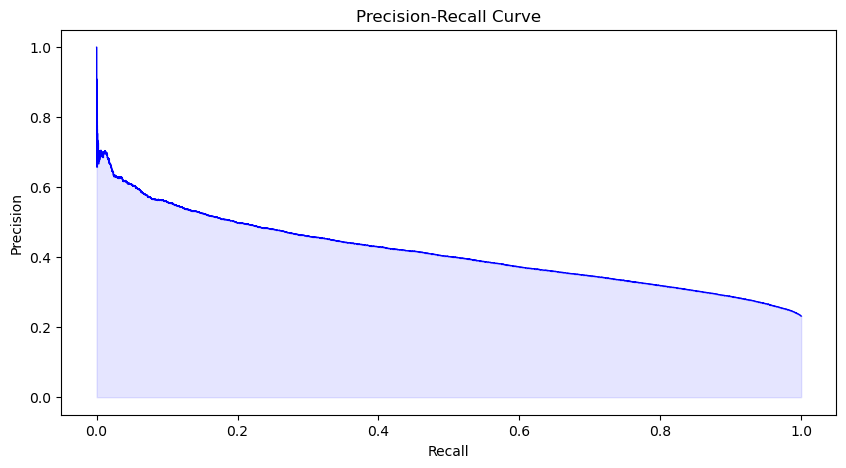

In [12]:
y_probs = best_algorithm.predict_proba(X_test_processed)[:,1]
y_pred = best_algorithm.predict(X_test_processed)

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Precision-Recall curve
plt.figure(figsize=(10,5))
plt.plot(recall, precision, color="b", lw=1)
plt.fill_between(recall, precision, alpha=0.1, color="blue")
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision');

### 7.1 Classification Report sem alteração na configuração padrão do Threshold (0.5)

In [13]:
# Avaliação do modelo ajustado
from sklearn.metrics import classification_report

print("Relatório de classificação com novo limiar:")
print(classification_report(y_test, y_pred))

Relatório de classificação com novo limiar:
              precision    recall  f1-score   support

           0       0.78      0.97      0.87    127685
           1       0.55      0.11      0.18     38532

    accuracy                           0.77    166217
   macro avg       0.67      0.54      0.52    166217
weighted avg       0.73      0.77      0.71    166217



### 7.2 Classification Report após alteração no Threshold

In [14]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Obtenção das probabilidades para a classe positiva
y_probs = best_algorithm.predict_proba(X_test_processed)[:, 1]

# Calcula Precision, Recall e os thresholds correspondentes
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Evitar divisão por zero - filtrando F1-Scores válidos
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)  # Pequeno valor para evitar divisão por zero

# Encontra o índice do threshold que maximiza o F1-Score
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

# Mostra o melhor threshold e o F1-Score correspondente
print(f"Melhor threshold para maximizar Precision e Recall: {best_threshold:.3f}")
print(f"F1-Score correspondente: {f1_scores[best_index]:.3f}")

# Aplica o novo limiar para ajustar as predições
y_pred_adjusted = (y_probs >= best_threshold).astype(int)

# Avaliação do modelo ajustado
from sklearn.metrics import classification_report

print("Relatório de classificação com novo limiar:")
print(classification_report(y_test, y_pred_adjusted))

Melhor threshold para maximizar Precision e Recall: 0.224
F1-Score correspondente: 0.464
Relatório de classificação com novo limiar:
              precision    recall  f1-score   support

           0       0.87      0.60      0.71    127685
           1       0.35      0.70      0.46     38532

    accuracy                           0.63    166217
   macro avg       0.61      0.65      0.59    166217
weighted avg       0.75      0.63      0.65    166217



## 8. Tunagem de hiperparâmetros

In [15]:
import optuna
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score
from optuna.samplers import TPESampler

# Função objetivo para otimização do XGBoost
def objective(trial):
    # Sugerir hiperparâmetros para o XGBoost
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 0,
        'use_label_encoder': False,
        'eval_metric': 'logloss'
    }

    # Definir o modelo XGBoost com os hiperparâmetros sugeridos
    model = XGBClassifier(**param)

    # Pipeline com preprocessador e modelo
    pipeline = Pipeline(steps=[('model', model)])

    # Treinar o pipeline
    pipeline.fit(X_train, y_train)

    # Prever as probabilidades no conjunto de validação
    y_pred_probs = pipeline.predict_proba(X_test)[:, 1]

    # Calcular AUC-ROC
    auc = roc_auc_score(y_test, y_pred_probs)

    return auc

# Classe para parada antecipada se não houver melhora após 20 iterações
class EarlyStoppingCallback:
    def __init__(self, patience: int):
        self.patience = patience
        self.best_score = None
        self.num_no_improvement = 0

    def __call__(self, study: optuna.study.Study, trial: optuna.trial.FrozenTrial):
        current_score = study.best_value
        if self.best_score is None or current_score > self.best_score:
            self.best_score = current_score
            self.num_no_improvement = 0
        else:
            self.num_no_improvement += 1

        if self.num_no_improvement >= self.patience:
            study.stop()

# Configurar o Early Stopping Callback
early_stopping = EarlyStoppingCallback(patience=20)

# Criar o estudo com a seed para reprodutibilidade
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=20, n_jobs=-1, callbacks=[early_stopping])

# Melhor conjunto de hiperparâmetros encontrado
print(f"Melhores hiperparâmetros: {study.best_params}")
print(f"Melhor AUC-ROC: {study.best_value:.4f}")

[I 2026-02-23 20:25:07,186] A new study created in memory with name: no-name-206ab085-d955-4a4b-a61f-76f463b5a863
c:\ProgramData\anaconda3\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2026-02-23 20:26:53,854] Trial 6 finished with value: 0.6996941670291595 and parameters: {'n_estimators': 78, 'max_depth': 3, 'learning_rate': 0.00011109807527182469, 'subsample': 0.8357829974659061, 'colsample_bytree': 0.5883591859574937, 'gamma': 2.1521533392419485e-07, 'reg_alpha': 0.0002527096510146238, 'reg_lambda': 9.368058964752922e-05, 'min_child_weight': 8}. Best is trial 6 with value: 0.6996941670291595.
[I 2026-02-23 20:28:12,787] Trial 7 finished with value: 0.7023587897517232 and parameters: {'n_estimators': 73, 'max_depth': 5, 'learning_rate': 0.00017929365980336125, 'subsample': 0.6144807190680486, 'colsample_bytree': 0.8204705236824145, 'gamma': 1.1099460215350714e-05, '

Melhores hiperparâmetros: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.08401916676797998, 'subsample': 0.9473130896443964, 'colsample_bytree': 0.9069261849785479, 'gamma': 6.27469705542997e-07, 'reg_alpha': 0.008485227468325755, 'reg_lambda': 0.00010374911004163387, 'min_child_weight': 6}
Melhor AUC-ROC: 0.7108


In [18]:
best_params = {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.08401916676797998, 'subsample': 0.9473130896443964, 'colsample_bytree': 0.9069261849785479, 'gamma': 6.27469705542997e-07, 'reg_alpha': 0.008485227468325755, 'reg_lambda': 0.00010374911004163387, 'min_child_weight': 6}

### 8.1 Treinar algoritmo com a melhor configuração de hiperparâmetros

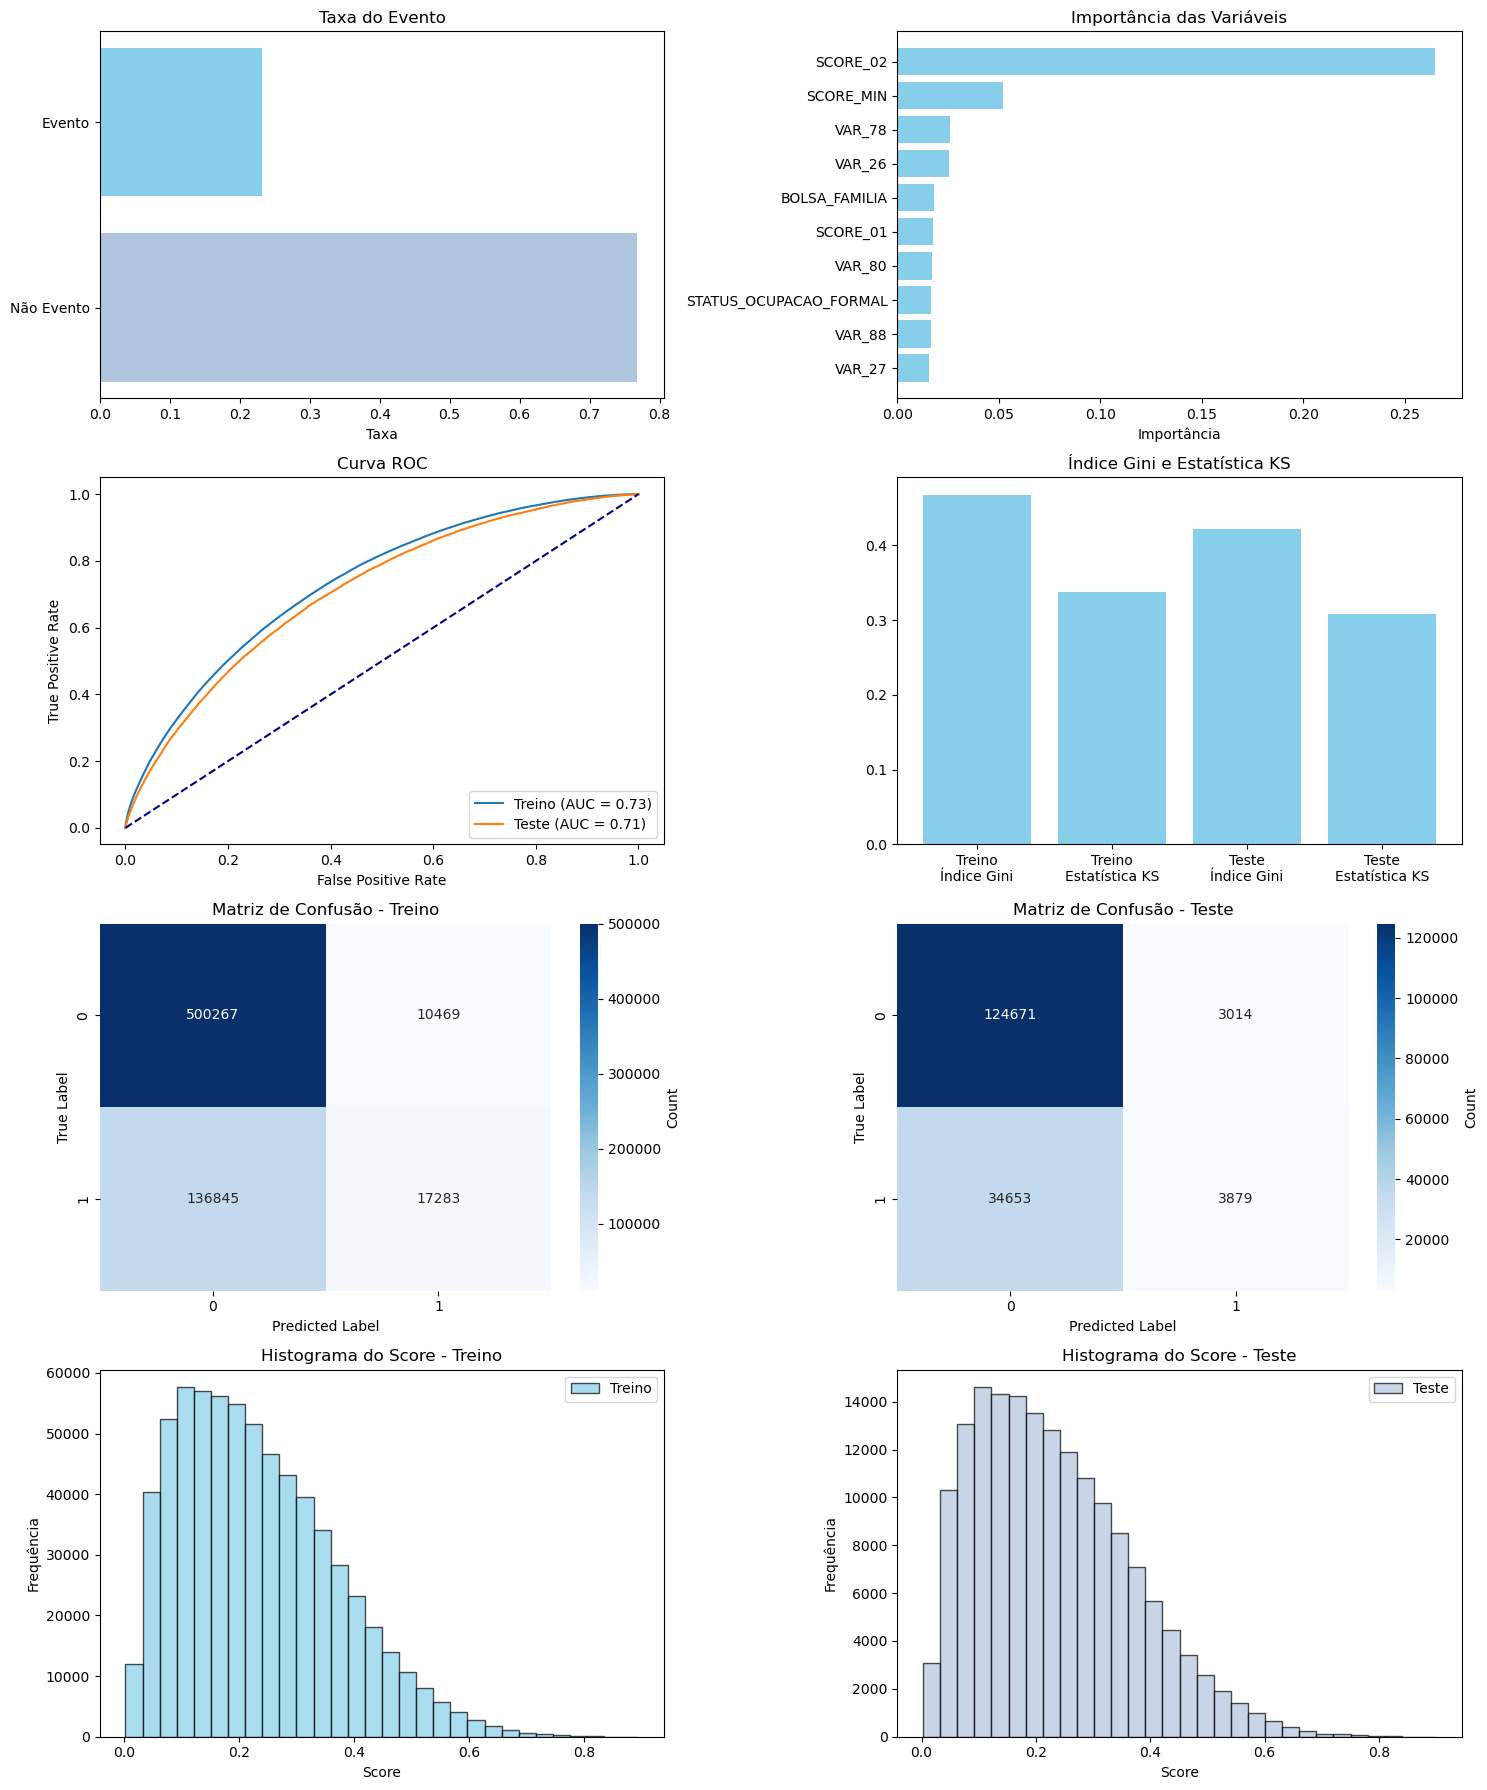

In [19]:
features = X_train_processed.columns
best_algorithm_tuned = XGBClassifier(random_state=0,**best_params)
best_algorithm_tuned.fit(X_train_processed,y_train)
plot_metrics(best_algorithm_tuned, X_train_processed, y_train, X_test_processed, y_test, features)

# features = X_train_processed.columns
# best_algorithm_tuned = XGBClassifier(random_state=0,**study.best_params)
# best_algorithm_tuned.fit(X_train_processed,y_train)
# plot_metrics(best_algorithm_tuned, X_train_processed, y_train, X_test_processed, y_test, features)

### 8.2 Curva Precision Recall após tunar algoritmo

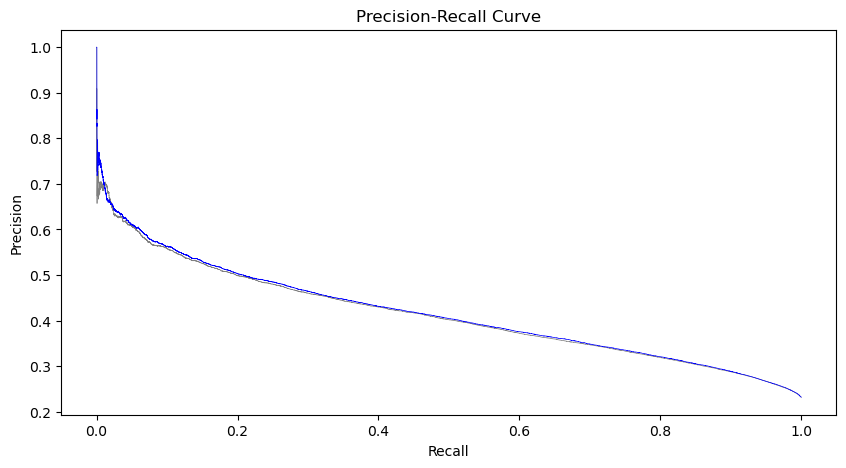

In [20]:
# Curva com algoritmo antes do tuning
y_probs = best_algorithm.predict_proba(X_test_processed)[:,1]
y_pred = best_algorithm.predict(X_test_processed)

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(10,5))
plt.plot(recall, precision, color="gray", lw=0.5)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision');

# ----------------------------------------------------------------------------

# Curva com algoritmo após o tuning
y_probs_tuned = best_algorithm_tuned.predict_proba(X_test_processed)[:,1]
y_pred_tuned = best_algorithm_tuned.predict(X_test_processed)

precision_tuned, recall_tuned, thresholds_tuned = precision_recall_curve(y_test, y_probs_tuned)

plt.plot(recall_tuned, precision_tuned, color="b", lw=0.5)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision');

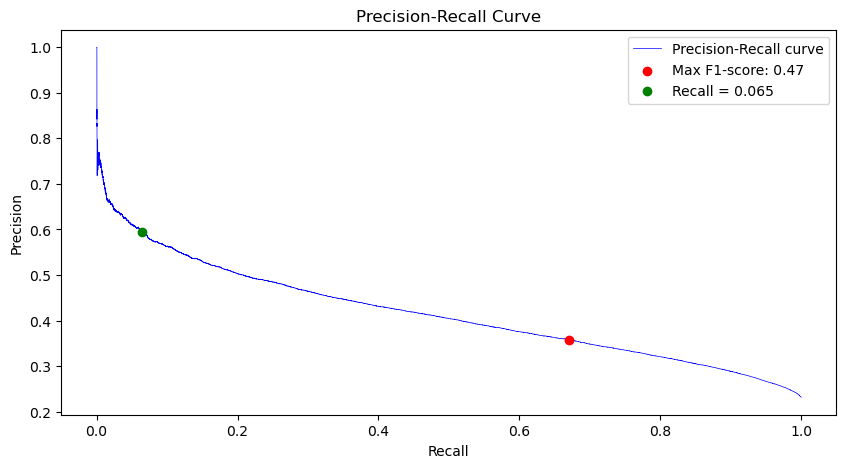

Priorizando a configuração de melhor F1-score:
Melhor F1-score: 0.4670
Threshold correspondente ao F1-score máximo: 0.2370326966047287
Precision: 0.35807666740527366
Recall: 0.6710266791238452
----------------------------------------------------------------------
Priorizando outra configuração com menor recall entretanto um maior precision:
Precision: 0.5944
Recall: 0.0650
Threshold: 0.5385063290596008
F1-score: 0.11718623489065856


In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve

# Supondo que você já tenha os arrays: y_true e y_pred_proba
precision_tuned, recall_tuned, thresholds_tuned = precision_recall_curve(y_test, y_probs_tuned)

# Calcular o F1-score para cada ponto
f1_scores = 2 * (precision_tuned * recall_tuned) / (precision_tuned + recall_tuned + 1e-32)

# Encontrar o índice que maximiza o F1-score
best_f1_index = np.argmax(f1_scores)
best_threshold = thresholds_tuned[best_f1_index - 1]  # -1 para alinhar com o tamanho do array de thresholds
best_f1_score = f1_scores[best_f1_index]

# Encontrar o índice onde o recall é aproximadamente 0.065
recall_target = 0.065
recall_index = (np.abs(recall_tuned - recall_target)).argmin()

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 5))
plt.plot(recall_tuned, precision_tuned, color='b', lw=0.5, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

# Marcar o ponto de F1-score máximo
plt.scatter(recall_tuned[best_f1_index], precision_tuned[best_f1_index], color='red', label=f'Max F1-score: {best_f1_score:.2f}', zorder=2)

# Marcar o ponto onde recall é 0.065
plt.scatter(recall_tuned[recall_index], precision_tuned[recall_index], color='green', label=f'Recall = {recall_target}', zorder=2)

plt.legend()
plt.show()

print('Priorizando a configuração de melhor F1-score:')
print(f'Melhor F1-score: {best_f1_score:.4f}')
print(f'Threshold correspondente ao F1-score máximo: {best_threshold}')
print(f'Precision: {precision_tuned[best_f1_index]}')
print(f'Recall: {recall_tuned[best_f1_index]}')

f1_score = 2 * (precision_tuned[recall_index] * recall_target) / (precision_tuned[recall_index] + recall_target + 1e-32)
print(70*'-')
print('Priorizando outra configuração com menor recall entretanto um maior precision:')
print(f'Precision: {precision_tuned[recall_index]:.4f}')
print(f'Recall: {recall_tuned[recall_index]:.4f}')
print(f'Threshold: {thresholds_tuned[recall_index-1]:.16f}')
print(f'F1-score: {f1_score}')


In [ ]:
# Exemplo de teste alterando o threshold
y_pred_aux = (y_probs_tuned >= 0.2370326966047287).astype(int)
print(classification_report(y_test, y_pred_aux))

              precision    recall  f1-score   support

           0       0.78      0.99      0.87    127685
           1       0.59      0.07      0.12     38532

    accuracy                           0.77    166217
   macro avg       0.69      0.53      0.49    166217
weighted avg       0.74      0.77      0.70    166217



## 9. Análise de variáveis importantes para o modelo

### 9.1 Visualização das 15 variáveis mais importantes

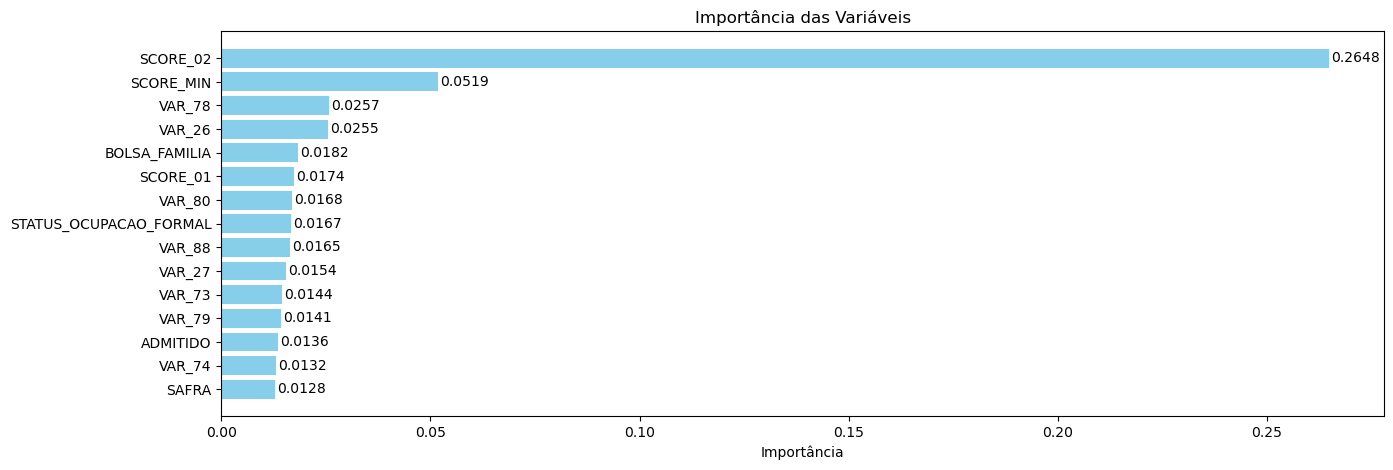

In [24]:
plt.figure(figsize=(15,5))

importances = best_algorithm_tuned.feature_importances_
indices = np.argsort(importances)  # Ordem ascendente
indices = indices[-15:]  # Considerando apenas as 15 mais importantes

plt.barh(features[indices], importances[indices], color='skyblue')
plt.xlabel('Importância')
plt.title('Importância das Variáveis')

# Adicionar os valores de importância ao lado de cada barra
for i, v in enumerate(importances[indices]):
    plt.text(v + 0.0005, i, f'{v:.4f}', va='center')  # Ajuste o valor necessário para espaçamento

plt.show()

### 9.2 Checar quantidade de variáveis que entraram no modelo

In [25]:
qtd_vars_modelo = (importances > 0).sum()
print(f'Quantidade de variáveis que entraram no modelo: {qtd_vars_modelo}')

Quantidade de variáveis que entraram no modelo: 66


### 9.3 Checar tempo para predição de uma instância

In [26]:
%%time
score_fraude = best_algorithm_tuned.predict_proba(X_test_processed.iloc[[0]])[:,1]

CPU times: total: 0 ns
Wall time: 2.99 ms


### 9.4 Checar desempenho do modelo

In [27]:
metricas = calculate_metrics('XGBoost',best_algorithm_tuned, X_train_processed, y_train, X_test_processed, y_test)
display(metricas)

,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,XGBoost,Treino,0.778430,0.622766,0.112134,0.733673,0.467347,0.338219
1,XGBoost,Teste,0.773387,0.562745,0.100670,0.710819,0.421638,0.308008


### 9.5 Selecionar as 50 variáveis mais importantes para o modelo e checar latência, desempenho

In [28]:
indices = np.argsort(importances)  # Ordem ascendente
indices = indices[-50:]  # Considerando apenas as 50 mais importantes
vars_selected_v1 = features[indices].to_list()

modelo_simplificado_v1 = best_algorithm_tuned.fit(X_train_processed[vars_selected_v1],y_train)

In [29]:
%%time
score_fraude = modelo_simplificado_v1.predict_proba(X_test_processed[vars_selected_v1].iloc[[0]])[:,1]

CPU times: total: 156 ms
Wall time: 52 ms


In [30]:
metricas = calculate_metrics('XGBoost',modelo_simplificado_v1, X_train_processed[vars_selected_v1], y_train, X_test_processed[vars_selected_v1], y_test)
display(metricas)

,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,XGBoost,Treino,0.778301,0.620885,0.112102,0.732112,0.464225,0.335187
1,XGBoost,Teste,0.773736,0.566298,0.102305,0.710947,0.421894,0.306591


### 9.6 Selecionar as 25 variáveis mais importantes para o modelo e checar latência, desempenho

In [31]:
indices = np.argsort(importances)  # Ordem ascendente
indices = indices[-25:]  # Considerando apenas as 25 mais importantes
vars_selected_v2 = features[indices].to_list()

modelo_simplificado_v2 = best_algorithm_tuned.fit(X_train_processed[vars_selected_v2],y_train)

In [32]:
%%time
score_fraude = modelo_simplificado_v2.predict_proba(X_test_processed[vars_selected_v2].iloc[[0]])[:,1]

CPU times: total: 312 ms
Wall time: 31.3 ms


In [33]:
metricas = calculate_metrics('XGBoost',modelo_simplificado_v2, X_train_processed[vars_selected_v2], y_train, X_test_processed[vars_selected_v2], y_test)
display(metricas)

,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,XGBoost,Treino,0.776613,0.603348,0.106171,0.723350,0.446699,0.322920
1,XGBoost,Teste,0.773242,0.562361,0.098412,0.709789,0.419578,0.304936


###9.7 Tunar hiperparâmetros da versão simplificada v1

### 9.7.1 Maximizando ROC-AUC

In [35]:
import optuna
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from optuna.samplers import TPESampler

# Definir o pipeline
cat_attributes_vars_selected_v1 = X_train[vars_selected_v1].select_dtypes(include='object')
num_attributes_vars_selected_v1 = X_train[vars_selected_v1].select_dtypes(exclude='object')

# Define categorical pipeline
cat_pipe_vars_selected_v1 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder())
])

# Define numerical pipeline
num_pipe_vars_selected_v1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

# Combine categorical and numerical pipelines
preprocessor_vars_selected_v1 = ColumnTransformer([
    ('cat', cat_pipe_vars_selected_v1, cat_attributes_vars_selected_v1.columns),
    ('num', num_pipe_vars_selected_v1, num_attributes_vars_selected_v1.columns)
])
preprocessor_vars_selected_v1 = Pipeline(steps=[("preprocessor", preprocessor_vars_selected_v1)])



# Inicializar os hiperparâmetros conhecidos
init_params = {
    'n_estimators': 497,
    'max_depth': 9,
    'learning_rate': 0.05064131970082176,
    'subsample': 0.9017014890228775,
    'colsample_bytree': 0.7349176134551406,
    'gamma': 3.357582904408152e-05,
    'reg_alpha': 0.9974231664030752,
    'reg_lambda': 3.4312469095456225e-05,
    'min_child_weight': 5
}

# Função objetivo para otimização do XGBoost
def objective(trial):
    # Sugerir hiperparâmetros para o XGBoost
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500) if trial.number > 0 else init_params['n_estimators'],
        'max_depth': trial.suggest_int('max_depth', 3, 10) if trial.number > 0 else init_params['max_depth'],
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True) if trial.number > 0 else init_params['learning_rate'],
        'subsample': trial.suggest_float('subsample', 0.5, 1.0) if trial.number > 0 else init_params['subsample'],
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0) if trial.number > 0 else init_params['colsample_bytree'],
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['gamma'],
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['reg_alpha'],
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['reg_lambda'],
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10) if trial.number > 0 else init_params['min_child_weight'],
        'random_state': 0,
        'eval_metric': 'logloss'
    }

    # Definir o modelo XGBoost com os hiperparâmetros sugeridos
    model = XGBClassifier(**param)

    # Pipeline com preprocessador e modelo
    pipeline_vars_selected_v1 = Pipeline(steps=[('preprocessor', preprocessor_vars_selected_v1),
                               ('model', model)])

    # Treinar o pipeline
    pipeline_vars_selected_v1.fit(X_train[vars_selected_v1], y_train)

    # Prever as probabilidades no conjunto de validação
    y_pred_probs = pipeline_vars_selected_v1.predict_proba(X_test[vars_selected_v1])[:, 1]

    # Calcular AUC-ROC
    auc = roc_auc_score(y_test, y_pred_probs)

    return auc

# Classe para parada antecipada se não houver melhora após 5 iterações
class EarlyStoppingCallback:
    def __init__(self, patience: int):
        self.patience = patience
        self.best_score = None
        self.num_no_improvement = 0

    def __call__(self, study: optuna.study.Study, trial: optuna.trial.FrozenTrial):
        current_score = study.best_value
        if self.best_score is None or current_score > self.best_score:
            self.best_score = current_score
            self.num_no_improvement = 0
        else:
            self.num_no_improvement += 1

        if self.num_no_improvement >= self.patience:
            study.stop()

# Configurar o Early Stopping Callback
early_stopping = EarlyStoppingCallback(patience=25)

# Criar o estudo com a seed para reprodutibilidade e ponto de partida nos hiperparâmetros conhecidos
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=20, n_jobs=-1, callbacks=[early_stopping])

# Melhor conjunto de hiperparâmetros encontrado
print(f"Melhores hiperparâmetros: {study.best_params}")
print(f"Melhor AUC-ROC: {study.best_value:.4f}")

[I 2026-02-23 22:37:30,850] A new study created in memory with name: no-name-afdd2b77-8a4e-480a-b485-597a472e78c3
[I 2026-02-23 22:38:59,160] Trial 39 finished with value: 0.7013402567536333 and parameters: {'n_estimators': 371, 'max_depth': 10, 'learning_rate': 0.09250543341972423, 'subsample': 0.6181295124058412, 'colsample_bytree': 0.9878845235156443, 'gamma': 6.824506446236487e-06, 'reg_alpha': 2.078456263632774e-08, 'reg_lambda': 0.023140503951657922, 'min_child_weight': 10}. Best is trial 8 with value: 0.7104144631165399.
[I 2026-02-23 22:41:36,996] Trial 6 finished with value: 0.6997177970052845 and parameters: {'n_estimators': 217, 'max_depth': 3, 'learning_rate': 0.00012577477219921139, 'subsample': 0.9904013028607044, 'colsample_bytree': 0.8741033893739694, 'gamma': 0.0001280387909493649, 'reg_alpha': 2.162549233299391e-06, 'reg_lambda': 2.5613803201919722e-05, 'min_child_weight': 3}. Best is trial 6 with value: 0.6997177970052845.
[I 2026-02-23 22:41:57,325] Trial 4 finished

Melhores hiperparâmetros: {'n_estimators': 303, 'max_depth': 7, 'learning_rate': 0.020007929802140556, 'subsample': 0.7561981064601235, 'colsample_bytree': 0.8939638718194769, 'gamma': 0.08942843075196766, 'reg_alpha': 1.2811571869424657e-08, 'reg_lambda': 4.815855958253978e-07, 'min_child_weight': 9}
Melhor AUC-ROC: 0.7104


### 9.7.2 Maximizando PR-AUC

In [36]:
import optuna
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from optuna.samplers import TPESampler

# Definir o pipeline
cat_attributes_vars_selected_v1 = X_train[vars_selected_v1].select_dtypes(include='object')
num_attributes_vars_selected_v1 = X_train[vars_selected_v1].select_dtypes(exclude='object')

# Define categorical pipeline
cat_pipe_vars_selected_v1 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder())
])

# Define numerical pipeline
num_pipe_vars_selected_v1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

# Combine categorical and numerical pipelines
preprocessor_vars_selected_v1 = ColumnTransformer([
    ('cat', cat_pipe_vars_selected_v1, cat_attributes_vars_selected_v1.columns),
    ('num', num_pipe_vars_selected_v1, num_attributes_vars_selected_v1.columns)
])
preprocessor_vars_selected_v1 = Pipeline(steps=[("preprocessor", preprocessor_vars_selected_v1)])



# Inicializar os hiperparâmetros conhecidos
init_params = {
    'n_estimators': 303,
    'max_depth': 7,
    'learning_rate':  0.020007929802140556,
    'subsample': 0.7561981064601235,
    'colsample_bytree': 0.8939638718194769,
    'gamma': 0.08942843075196766,
    'reg_alpha': 1.2811571869424657e-08,
    'reg_lambda': 4.815855958253978e-07,
    'min_child_weight': 5
}

# Função objetivo para otimização do XGBoost
def objective(trial):
    # Sugerir hiperparâmetros para o XGBoost
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500) if trial.number > 0 else init_params['n_estimators'],
        'max_depth': trial.suggest_int('max_depth', 3, 10) if trial.number > 0 else init_params['max_depth'],
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True) if trial.number > 0 else init_params['learning_rate'],
        'subsample': trial.suggest_float('subsample', 0.5, 1.0) if trial.number > 0 else init_params['subsample'],
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0) if trial.number > 0 else init_params['colsample_bytree'],
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['gamma'],
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['reg_alpha'],
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['reg_lambda'],
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10) if trial.number > 0 else init_params['min_child_weight'],
        'random_state': 0,
        'eval_metric': 'logloss'
    }

    # Definir o modelo XGBoost com os hiperparâmetros sugeridos
    model = XGBClassifier(**param)

    # Pipeline com preprocessador e modelo
    pipeline_vars_selected_v1 = Pipeline(steps=[('preprocessor', preprocessor_vars_selected_v1),
                               ('model', model)])

    # Treinar o pipeline
    pipeline_vars_selected_v1.fit(X_train[vars_selected_v1], y_train)

    # Prever as probabilidades no conjunto de validação
    y_pred_probs = pipeline_vars_selected_v1.predict_proba(X_test[vars_selected_v1])[:, 1]

    # Calcular average precision (AUC-PR)
    avg_precision = average_precision_score(y_test, y_pred_probs)

    return avg_precision

# Classe para parada antecipada se não houver melhora após 5 iterações
class EarlyStoppingCallback:
    def __init__(self, patience: int):
        self.patience = patience
        self.best_score = None
        self.num_no_improvement = 0

    def __call__(self, study: optuna.study.Study, trial: optuna.trial.FrozenTrial):
        current_score = study.best_value
        if self.best_score is None or current_score > self.best_score:
            self.best_score = current_score
            self.num_no_improvement = 0
        else:
            self.num_no_improvement += 1

        if self.num_no_improvement >= self.patience:
            study.stop()

# Configurar o Early Stopping Callback
early_stopping = EarlyStoppingCallback(patience=25)

# Criar o estudo com a seed para reprodutibilidade e ponto de partida nos hiperparâmetros conhecidos
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=20, n_jobs=-1, callbacks=[early_stopping])

# Melhor conjunto de hiperparâmetros encontrado
print(f"Melhores hiperparâmetros: {study.best_params}")
print(f"Melhor AUC-PR: {study.best_value:.4f}")

[I 2026-02-23 22:59:51,982] A new study created in memory with name: no-name-68b4669f-59bd-4be4-bb4e-24abf00b6326
[I 2026-02-23 23:01:22,223] Trial 8 finished with value: 0.3973058838689897 and parameters: {'n_estimators': 79, 'max_depth': 3, 'learning_rate': 0.00017055137554109788, 'subsample': 0.7502682340133728, 'colsample_bytree': 0.7645383426099348, 'gamma': 1.1017303084111878e-05, 'reg_alpha': 1.1194041648823892e-08, 'reg_lambda': 0.017780756074227657, 'min_child_weight': 8}. Best is trial 8 with value: 0.3973058838689897.
[I 2026-02-23 23:02:48,897] Trial 11 finished with value: 0.41357696765315693 and parameters: {'n_estimators': 69, 'max_depth': 5, 'learning_rate': 0.08237268646364146, 'subsample': 0.7499117542938684, 'colsample_bytree': 0.9230151592465313, 'gamma': 0.0004963558293240907, 'reg_alpha': 0.0010426301192281806, 'reg_lambda': 0.08462512776824578, 'min_child_weight': 1}. Best is trial 11 with value: 0.41357696765315693.
[I 2026-02-23 23:02:54,621] Trial 19 finished 

Melhores hiperparâmetros: {'n_estimators': 435, 'max_depth': 8, 'learning_rate': 0.022656891709973127, 'subsample': 0.8435600594083816, 'colsample_bytree': 0.612488163779731, 'gamma': 9.805948431758596e-05, 'reg_alpha': 0.0005752989331004169, 'reg_lambda': 4.249815899017231e-06, 'min_child_weight': 6}
Melhor AUC-PR: 0.4175


Treinar algoritmo com melhor configuração de hiperparâmetros

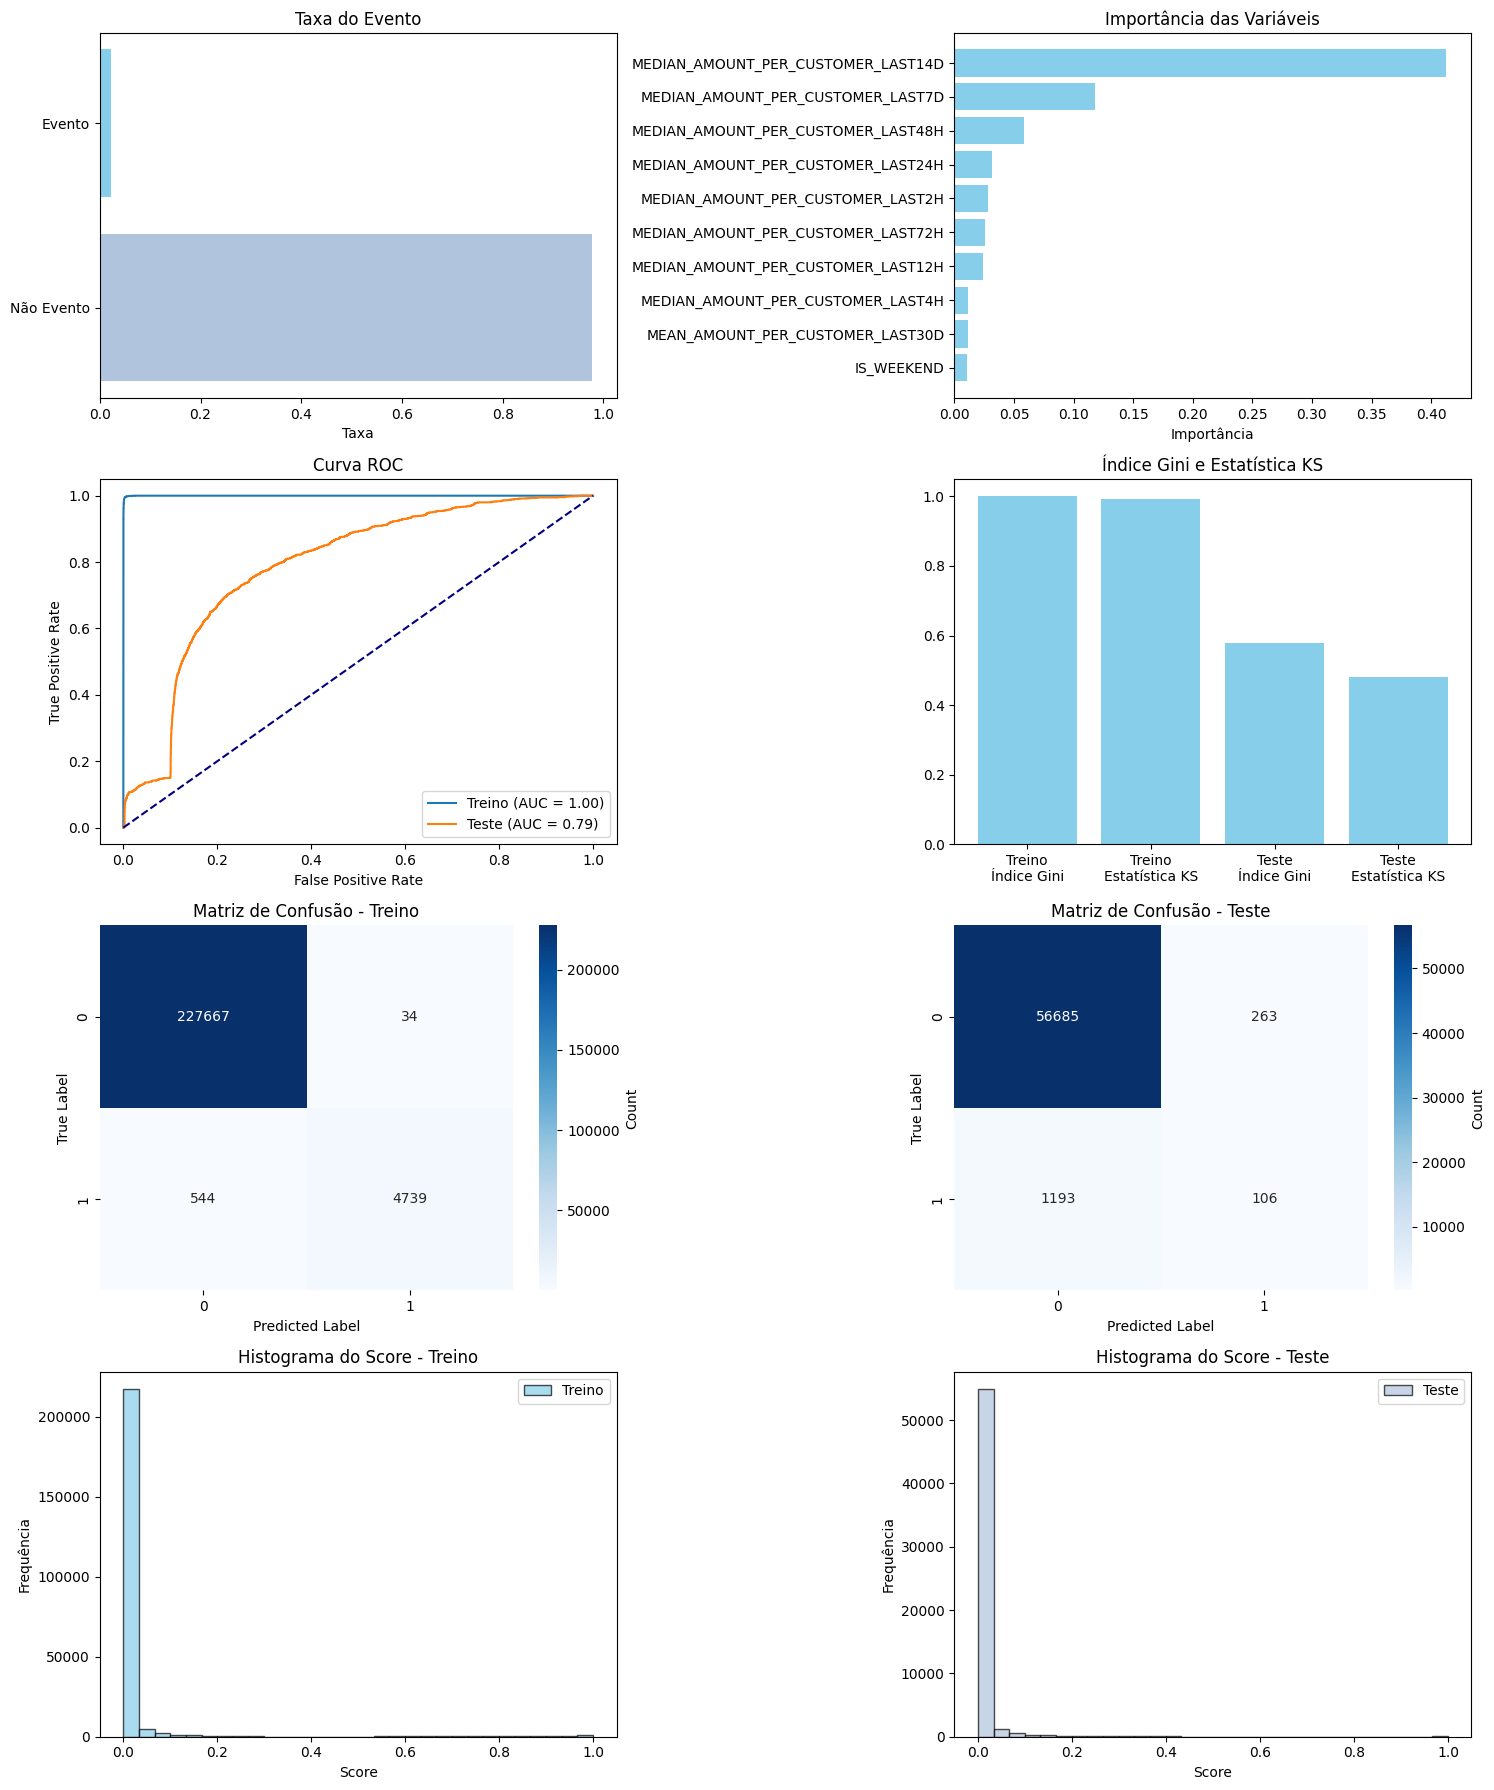

In [ ]:
best_params = {'n_estimators': 497, 'max_depth': 9, 'learning_rate': 0.05064131970082176, 'subsample': 0.9017014890228775, 'colsample_bytree': 0.7349176134551406, 'gamma': 3.357582904408152e-05, 'reg_alpha': 0.9974231664030752, 'reg_lambda': 3.4312469095456225e-05, 'min_child_weight': 5}

features = X_train_processed.columns
# modelo_simplificado_v1_tuned = best_algorithm_tuned = XGBClassifier(random_state=0,**study.best_params)
modelo_simplificado_v1_tuned = best_algorithm_tuned = XGBClassifier(random_state=0,**best_params)
modelo_simplificado_v1_tuned.fit(X_train_processed[vars_selected_v1],y_train)
plot_metrics(best_algorithm_tuned, X_train_processed[vars_selected_v1], y_train, X_test_processed[vars_selected_v1], y_test, features)

y_simplificado_probs_tuned = modelo_simplificado_v1_tuned.predict_proba(X_test_processed[vars_selected_v1])[:,1]

### 9.8 Ajuste no threshold

Como não houve mudança no modelo após tunar hiperparâmetros, não precisaremos reajustar o threshold. Entretanto, se houvesse alguma mudança durante a etapa de tuning, seria necessário reajustar o threshold para avaliar o desempenho (Precision e Recall).

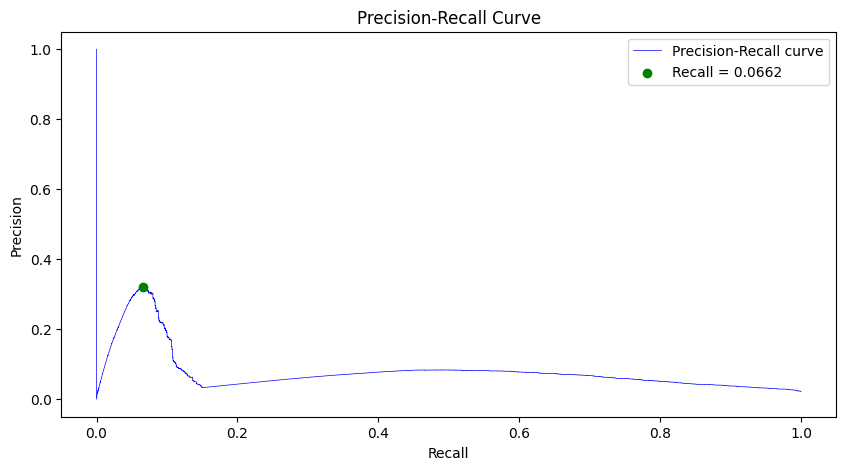

Priorizando a configuração de melhor F1-score:
Melhor F1-score: 0.1436
Threshold correspondente ao F1-score máximo: 4.336140409577638e-05
Precision: 0.08379528168106226
Recall: 0.5003849114703618
----------------------------------------------------------------------
Priorizando outra configuração com menor recall entretanto um maior precision:
Precision: 0.3209
Recall: 0.0662
Threshold: 0.6762828826904297
F1-score: 0.10975732011073666


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve

# Supondo que você já tenha os arrays: y_true e y_pred_proba
precision_simplificado_tuned, recall_simplificado_tuned, thresholds_tuned = precision_recall_curve(y_test, y_simplificado_probs_tuned)

# Calcular o F1-score para cada ponto
f1_scores = 2 * (precision_simplificado_tuned * recall_simplificado_tuned) / (precision_simplificado_tuned + recall_simplificado_tuned + 1e-32)

# Encontrar o índice que maximiza o F1-score
best_f1_index = np.argmax(f1_scores)
best_threshold = thresholds_tuned[best_f1_index - 1]  # -1 para alinhar com o tamanho do array de thresholds
best_f1_score = f1_scores[best_f1_index]

# Encontrar o índice onde o recall é aproximadamente 0.0662
recall_target = 0.0662
recall_index = (np.abs(recall_simplificado_tuned - recall_target)).argmin()

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 5))
plt.plot(recall_simplificado_tuned, precision_simplificado_tuned, color='b', lw=0.5, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

# Marcar o ponto onde recall é 0.0662
plt.scatter(recall_simplificado_tuned[recall_index], precision_simplificado_tuned[recall_index], color='green', label=f'Recall = {recall_target}', zorder=2)

plt.legend()
plt.show()

print('Priorizando a configuração de melhor F1-score:')
print(f'Melhor F1-score: {best_f1_score:.4f}')
print(f'Threshold correspondente ao F1-score máximo: {best_threshold}')
print(f'Precision: {precision_simplificado_tuned[best_f1_index]}')
print(f'Recall: {recall_simplificado_tuned[best_f1_index]}')

f1_score = 2 * (precision_simplificado_tuned[recall_index] * recall_target) / (precision_simplificado_tuned[recall_index] + recall_target + 1e-32)
print(70*'-')
print('Priorizando outra configuração com menor recall entretanto um maior precision:')
print(f'Precision: {precision_simplificado_tuned[recall_index]:.4f}')
print(f'Recall: {recall_simplificado_tuned[recall_index]:.4f}')
print(f'Threshold: {thresholds_tuned[recall_index-1]:.16f}')
print(f'F1-score: {f1_score}')

### 9.9 Avaliação dos resultados por mês de referência

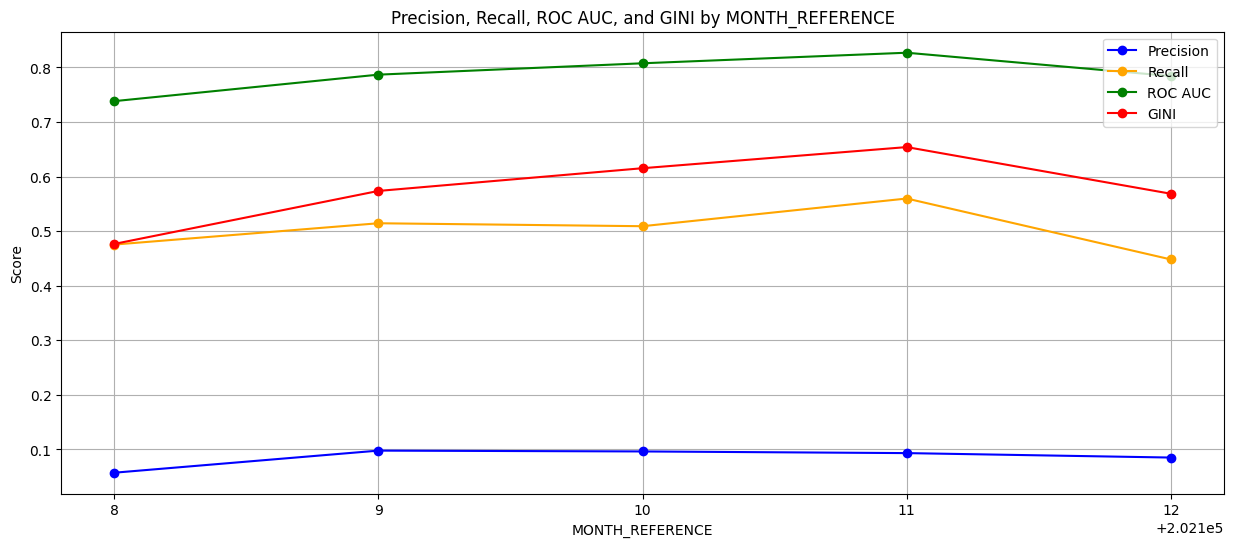

In [ ]:
from sklearn.metrics import roc_auc_score

# Lista para armazenar os resultados
results = []

base_teste_vars_pred = X_test_processed[vars_selected_v1].copy()
base_teste_vars_pred.loc[:,'TX_FRAUDE'] = y_test.reset_index(drop=True)
base_teste_vars_pred.loc[:,'SCORE_FRAUDE'] = y_simplificado_probs_tuned
base_teste_vars_pred.loc[:,'PRED_FRAUDE'] = (y_simplificado_probs_tuned >= best_threshold).astype(int)
base_teste_vars_pred.loc[:,'MONTH_REFERENCE'] = X_test['MONTH_REFERENCE'].reset_index(drop=True)

base_scores = X_test.copy()
base_scores.loc[:,'SCORE_FRAUDE_XGBOOST'] = y_simplificado_probs_tuned
base_scores.loc[:,'PRED_FRAUDE_XGBOOST'] = (y_simplificado_probs_tuned >= best_threshold).astype(int)

# Calcular precision, recall, roc_auc e gini por safra
for safra in base_teste_vars_pred['MONTH_REFERENCE'].unique():
    subset = base_teste_vars_pred[base_teste_vars_pred['MONTH_REFERENCE'] == safra]

    # Precision e Recall
    precision = precision_score(subset['TX_FRAUDE'], subset['PRED_FRAUDE'], zero_division=0)
    recall = recall_score(subset['TX_FRAUDE'], subset['PRED_FRAUDE'], zero_division=0)

    # ROC AUC
    if subset['TX_FRAUDE'].nunique() > 1:  # Garantir que existem ambas as classes (0 e 1)
        roc_auc = roc_auc_score(subset['TX_FRAUDE'], subset['SCORE_FRAUDE'])
    else:
        roc_auc = 0.5  # Valor neutro quando só há uma classe

    # GINI
    gini = 2 * roc_auc - 1

    # Armazenar os resultados
    results.append({
        'MONTH_REFERENCE': safra,
        'precision': precision,
        'recall': recall,
        'roc_auc': roc_auc,
        'gini': gini
    })

# Criar um DataFrame com os resultados
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='MONTH_REFERENCE')

# Converter a coluna 'MONTH_REFERENCE' para int
results_df['MONTH_REFERENCE'] = results_df['MONTH_REFERENCE'].astype(int)

# Plotar gráficos de linhas
plt.figure(figsize=(15, 6))

# Precision e Recall
plt.plot(results_df['MONTH_REFERENCE'], results_df['precision'], marker='o', label='Precision', color='blue')
plt.plot(results_df['MONTH_REFERENCE'], results_df['recall'], marker='o', label='Recall', color='orange')

# ROC AUC e GINI
plt.plot(results_df['MONTH_REFERENCE'], results_df['roc_auc'], marker='o', label='ROC AUC', color='green')
plt.plot(results_df['MONTH_REFERENCE'], results_df['gini'], marker='o', label='GINI', color='red')

plt.title('Precision, Recall, ROC AUC, and GINI by MONTH_REFERENCE')
plt.xlabel('MONTH_REFERENCE')
plt.ylabel('Score')
plt.xticks(results_df['MONTH_REFERENCE'])  # Adicionar ticks no eixo x
plt.grid()
plt.legend()
plt.show()

In [ ]:
results_df

,MONTH_REFERENCE,precision,recall,roc_auc,gini
4,202108,0.057284,0.475410,0.738273,0.476546
3,202109,0.097796,0.514493,0.786856,0.573711
2,202110,0.096286,0.509091,0.807688,0.615376
0,202111,0.093238,0.559829,0.827048,0.654096
1,202112,0.085091,0.448148,0.784280,0.568561


In [ ]:
# Taxa média de fraude na base
avg_fraud = base_teste_vars_pred.TX_FRAUDE.mean()

ref_fraud = base_teste_vars_pred.groupby('MONTH_REFERENCE')['TX_FRAUDE'].mean().reset_index().rename(columns={'TX_FRAUDE':'AVG_FRAUD_PER_MONTH_REFERENCE'})

print(f'Taxa média de fraude na base: {100*avg_fraud:.2f}%')

ref_fraud

Taxa média de fraude na base: 2.23%


,MONTH_REFERENCE,AVG_FRAUD_PER_MONTH_REFERENCE
0,202108.0,0.020586
1,202109.0,0.023836
2,202110.0,0.023339
3,202111.0,0.020353
4,202112.0,0.023407


In [ ]:
# Exportar o DataFrame para um arquivo Excel (.xlsx)
base_teste_vars_pred.to_excel('base_teste_vars_pred.xlsx', index=False)

from google.colab import files

# Baixar o arquivo Excel gerado
files.download('base_teste_vars_pred.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9.10 Salvar base com scores dados pelo Random Forest

In [ ]:
# Testar outros modelos
algoritmo = RandomForestClassifier(random_state=0)

# Treino do modelo
algoritmo.fit(X_train_processed,y_train)

# Realizar predições
base_scores['SCORE_FRAUDE_RANDOM_FOREST'] = algoritmo.predict_proba(X_test_processed)[:,1]
base_scores['PRED_FRAUDE_RANDOM_FOREST'] = algoritmo.predict(X_test_processed)

# Marcar o target
base_scores['TX_FRAUDE'] = y_test.copy()

# Exportar o DataFrame para um arquivo Excel (.xlsx)
base_scores.to_excel('base_scores.xlsx', index=False)

from google.colab import files

# Baixar o arquivo Excel gerado
files.download('base_scores.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>